
<p style="display:block;text-align:center;font-weight:700;font-size:40px">
  <em>Эссе №3</em>
</p>

<p style="display:block;text-align:center;font-style:italic;font-weight:700;font-size:40px">
  <em>Байесовская оценка вероятности ошибки радиоканала (BSC) по наблюдаемому битовому потоку</em>
</p>

## **Теория**

##### **Двоичный симметричный канал (Binary Symmetric Channel, BSC)**
- **Определение.** Простая модель цифровой линии связи: передаётся бит \(X \in \{0,1\}\), на выходе наблюдается бит \(Y\), и каждый бит искажается независимо с одной и той же вероятностью ошибки \(p\).
- **Вероятности переходов.**
  $$
    \Pr(Y = X) = 1 - p,\quad 
    \Pr(Y \ne X) = p.
  $$
  Матрица переходных вероятностей:
  $$
    P(y|x) = 
    \begin{pmatrix}
      \Pr(Y=0|X=0) & \Pr(Y=1|X=0) \\
      \Pr(Y=0|X=1) & \Pr(Y=1|X=1)
    \end{pmatrix}
    =
    \begin{pmatrix}
      1-p & p \\
      p & 1-p
    \end{pmatrix}.
  $$
- **Свойства.**
  - **Симметричный:** вероятность ошибки одинакова для 0 и 1.
  - **Без памяти:** ошибки по разным позициям независимы.
  - Хорошая первая модель для радиоканала с редкими независимыми ошибками битов.

---

##### **Вероятность ошибки бита и BER**
- **Вероятность ошибки бита** в модели BSC — это параметр $p$ в формулах выше:  
  $$
    p = \Pr(Y \ne X).
  $$
- **BER (Bit Error Rate)** на практике оценивают по длинной последовательности:
$$  
    \widehat{\text{BER}} = \frac{k}{n},
  $$
  где $k$ — число ошибочных битов (позиции, где $Y \ne X$), $n$  — общее число переданных битов.
- **Интерпретация в радиосвязи.**
  - Чем меньше BER, тем «чище» канал и выше качество радиолинии.
  - BER используют для:
    - выбора схемы модуляции/кодирования (адаптация MCS);
    - мониторинга качества link’а (радиорелейки, Wi-Fi, сотовые сети);
    - тестирования линии (BERT-тестеры, измерения в лаборатории).

---

##### **Биномиальная модель числа ошибок**
- При фиксированном $p$ и длине блока $n$ число ошибок $K$ (сколько раз $Y \ne X$) подчиняется **биномиальному распределению**:
$$  
    K \sim \mathrm{Bin}(n, p).
  $$
- **Формула вероятности**:
$$  
    \Pr(K = k \mid p) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,1,\dots,n.
  $$
- **Связь с моделью радиоканала.**
  - Каждый бит — «независимый эксперимент»: ошибка/нет.
  - Блок из $n$ бит — это $n$ испытаний с вероятностью «успеха» $p$ (здесь успех = ошибка).

---

##### **Оценка максимального правдоподобия (ML) для $p$**
- Наблюдаем:
  - переданные биты $X_1,\dots,X_n$,
  - принятые биты $Y_1,\dots,Y_n$,
  - число ошибок $k = \#\{i : X_i \ne Y_i\}$.
- При фиксированном $p$ вероятность наблюдать именно $k$ ошибок задаётся биномиальной моделью:
$$  
    \Pr(K = k \mid p) = \binom{n}{k} p^k(1-p)^{n-k}.
  $$
- **Оценка максимального правдоподобия (Maximum Likelihood, ML)** выбирает то значение \(p\), которое максимизирует эту вероятность.
- Для биномиального распределения получается простая формула:
$$  
    \hat p_{\text{ML}} = \frac{k}{n}.
  $$
- **Интерпретация.**
  - Это обычная частотная оценка BER: доля ошибочных битов.
  - При больших \(n\) $\hat p_{\text{ML}}$ хорошо приближается к истинному \(p\), но при малых \(n\) сильно шумит (может быть даже \(0\), если ошибок не случилось).

---

##### **Байесовская оценка вероятности ошибки**
- Подход **Байеса**: считаем $p$ неизвестным случайным параметром и задаём ему **априорное распределение** $P(p)$, которое отражает наши ожидания до наблюдений.
- После того как мы увидели данные (количество ошибок $k$ при $n$ битах), обновляем наше мнение:
   $$
    P(p \mid k) \propto P(k \mid p)\, P(p),
  $$
  где:
  - $P(k \mid p)$ — правдоподобие (биномиальная модель),
  - $P(p)$ — априорное распределение,
  - $P(p \mid k)$ — **апостериорное распределение** (обновлённое знание о \(p\)).
- Удобный выбор априора для биномиальной модели — **бета-распределение** $\mathrm{Beta}(\alpha,\beta)$.  
  При этом:
  $$
    P(p) \propto p^{\alpha-1}(1-p)^{\beta-1}, \quad 0 < p < 1.
  $$
- Если до наблюдений мы выбираем, например, «равномерный» априор \(\mathrm{Beta}(1,1)\), то после наблюдения \(k\) ошибок из \(n\):
  $$
    P(p \mid k) = \mathrm{Beta}(\alpha', \beta'),\quad
    \alpha' = 1 + k,\quad \beta' = 1 + (n-k).
  $$
- **Байесовская точечная оценка** (например, математическое ожидание апостериорного распределения):
  $$
    \hat p_{\text{Bayes}} = \mathbb{E}[p \mid k] = \frac{\alpha'}{\alpha' + \beta'} = \frac{k+1}{n+2}
  $$
  при $\alpha=\beta=1$.
- **Плюсы байесовского подхода для радиосвязи.**
  - Дает **интервальные оценки**: можно сказать не только «$\hat p \approx 0.01$», но и «с 95% доверия $p$ лежит в таком-то интервале».
  - Можно учитывать **априорное знание** о канале (например, что он обычно «хороший» и $p$ маленькое).
  - При малом числе наблюдений байесовская оценка обычно устойчивее, чем голая частотная $k/n$.

---

## **Цель**

Показать, как различными статистическими методами можно оценивать вероятность битовой ошибки в двоичном симметричном канале, сравнить устойчивость частотной, ML- и байесовской оценок, и понять, как объём наблюдений влияет на точность и разброс результата.


## **Практика**

In [226]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Фиксируем зерно ГПСЧ для воспроизводимости
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12


In [227]:
def generate_bits(n: int, rng=rng):
    """
    Генерирует случайную последовательность из n битов (0/1).
    """
    if rng is None:
        rng = np.random.default_rng()
    return rng.integers(0, 2, size=n, dtype=int)


def bsc_channel(x_bits, p: float, rng=rng):
    """
    Пропускает битовую последовательность x_bits через двоичный симметричный канал с вероятностью ошибки p.
    Возвращает принятую последовательность y_bits и вектор индикаторов ошибок.
    """
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be in [0, 1].")

    if rng is None:
        rng = np.random.default_rng()

    x_bits = np.asarray(x_bits, dtype=int)
    n = x_bits.size
    
    # для каждого бита бросаем "монетку": будет ли ошибка
    error_mask = rng.random(n) < p  # True там, где произошла ошибка
    
    # ошибка реализуется как XOR с 1
    y_bits = x_bits ^ error_mask.astype(int)
    
    return y_bits, error_mask.astype(int)


In [228]:
def estimate_p_ml(x_bits, y_bits):
    """
    Оценивает вероятность ошибки по методу максимального правдоподобия (частотная оценка):
    p_hat = число ошибок / число битов.
    """
    x_bits = np.asarray(x_bits, dtype=int)
    y_bits = np.asarray(y_bits, dtype=int)
    
    assert x_bits.shape == y_bits.shape
    
    errors = (x_bits != y_bits).astype(int)
    k = errors.sum()
    n = errors.size
    p_hat = k / n if n > 0 else np.nan
    return p_hat, k, n

In [229]:
def run_single_experiment(p_true: float, n_bits: int, rng=rng):
    """
    Запускает один эксперимент:
    - генерирует n_bits случайных битов,
    - пропускает через BSC(p_true),
    - возвращает оценку p_hat_ML, число ошибок k и длину n.
    """
    x = generate_bits(n_bits, rng=rng)
    y, err_mask = bsc_channel(x, p_true, rng=rng)
    p_hat_ml, k_errors, n = estimate_p_ml(x, y)
    return p_hat_ml, k_errors, n


Посмотрим, как меняется оценка при разных длинах последовательности бит.

In [230]:
# Посмотрим, как меняется оценка при разных длинах блока
p_true = 0.05
n_list = [100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000]

results = []

for n_bits in n_list:
    p_hat_ml, k_errors, n = run_single_experiment(p_true, n_bits, rng=rng)
    results.append((n_bits, p_hat_ml, k_errors))
    print(f"n = {n_bits:6d} | k = {k_errors:6d} ошибок | p_hat_ML = {p_hat_ml:.4f}")

results

n =    100 | k =      6 ошибок | p_hat_ML = 0.0600
n =   1000 | k =     44 ошибок | p_hat_ML = 0.0440
n =  10000 | k =    486 ошибок | p_hat_ML = 0.0486
n = 100000 | k =   5018 ошибок | p_hat_ML = 0.0502
n = 1000000 | k =  49727 ошибок | p_hat_ML = 0.0497
n = 10000000 | k = 499516 ошибок | p_hat_ML = 0.0500


[(100, np.float64(0.06), np.int64(6)),
 (1000, np.float64(0.044), np.int64(44)),
 (10000, np.float64(0.0486), np.int64(486)),
 (100000, np.float64(0.05018), np.int64(5018)),
 (1000000, np.float64(0.049727), np.int64(49727)),
 (10000000, np.float64(0.0499516), np.int64(499516))]

Видим, что для маленьких n оценка шумная, а для больших — очень близка к p_true.   
Теперь хотим посмотреть на **разброс** оценки $\hat p_{\text{ML}}$: насколько сильно она колеблется от эксперимента к эксперименту.    


Сейчас для каждого значения $n$ мы будем делать несколько независимых прогонов
и смотреть среднее значение $\mathbb{E}[\hat p_{\text{ML}}]$ и стандартное отклонение (разброс)/

In [231]:
def collect_ml_estimates(p_true: float, n_bits_list, n_trials: int = 50, rng=rng):
    """
    Для каждого n из n_bits_list запускает n_trials независимых экспериментов
    и возвращает словарь:
      n -> массив оценок p_hat_ML длины n_trials
    """
    estimates = {}
    for n_bits in n_bits_list:
        p_hats = []
        for _ in range(n_trials):
            p_hat_ml, k_errors, n = run_single_experiment(p_true, n_bits, rng=rng)
            p_hats.append(p_hat_ml)
        estimates[n_bits] = np.array(p_hats)
    return estimates


p_true = 0.05
n_bits_list = [100, 1_000, 10_000, 100_000]
n_trials = 400

ml_estimates = collect_ml_estimates(p_true, n_bits_list, n_trials=n_trials, rng=rng)

# Посчитаем среднее и стандартное отклонение для каждого n
for n_bits in n_bits_list:
    vals = ml_estimates[n_bits]
    mean_val = vals.mean()
    std_val = vals.std(ddof=1)
    theo_std = np.sqrt(p_true*(1-p_true)/n_bits)
    print(f"n={n_bits:6d} | mean={mean_val:.4f} | std={std_val:.4f} | theo_std={theo_std:.4f}")


n=   100 | mean=0.0490 | std=0.0213 | theo_std=0.0218
n=  1000 | mean=0.0495 | std=0.0068 | theo_std=0.0069
n= 10000 | mean=0.0500 | std=0.0022 | theo_std=0.0022
n=100000 | mean=0.0501 | std=0.0007 | theo_std=0.0007


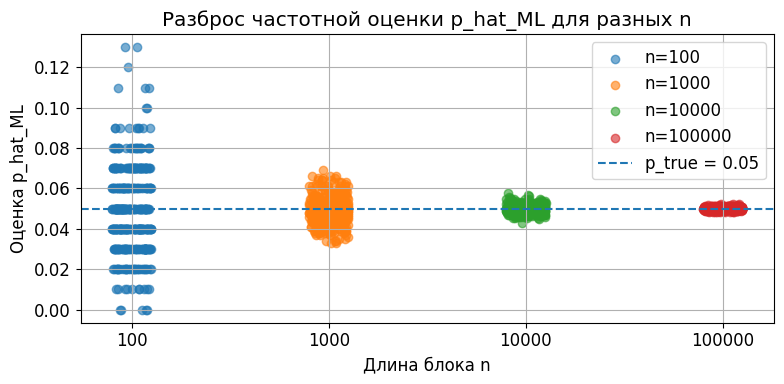

In [232]:
# Визуализируем разброс оценок: для каждого n нанесём точки p_hat_ML
plt.figure(figsize=(8,4))

for i, n_bits in enumerate(n_bits_list):
    vals = ml_estimates[n_bits]
    # Немного раздвинем точки по оси x, чтобы они не слипались
    x_coords = np.full(vals.size, i, dtype=float) + (rng.random(vals.size) - 0.5)*0.2
    plt.scatter(x_coords, vals, alpha=0.6, label=f"n={n_bits}")

# Линия истинного p_true
plt.axhline(p_true, linestyle="--", label=f"p_true = {p_true}")

plt.xticks(range(len(n_bits_list)), [str(n) for n in n_bits_list])
plt.xlabel("Длина блока n")
plt.ylabel("Оценка p_hat_ML")
plt.title("Разброс частотной оценки p_hat_ML для разных n")
plt.legend()
plt.tight_layout()
plt.show()


При маленьком $n$ оценка шумная, т к число ошибок $k$ сильно флуктуирует, при увеличении $n$ оценка стабилизируется около $p_{true}$

Теперь посмотрим, как можно оценивать $p$ в байесовском подходе.

Будем считать, что до наблюдений мы ничего не знаем о $p$ внутри $[0, 1]$  
и берём равномерное априорное распределение $P(p) = \mathrm{Beta}(1, 1)$.

Тогда, если мы наблюдали $k$ ошибок в $n$ битах, апостериорное распределение имеет вид:

$$
P(p \mid k, n) \propto p^k (1-p)^{n-k},
$$

то есть является распределением $\mathrm{Beta}(k+1, n-k+1)$.

Мы будем:

- считать $k$ и $n$ по данным эксперимента;
- строить апостериорную плотность $P(p \mid k, n)$ на сетке по $p$;
- сравнивать:
  - частотную оценку $\hat p_{\text{ML}} = k/n$,
  - байесовскую оценку (например, среднее апостериорного распределения),
  - истинное значение $p_{\text{true}}$.

In [233]:
def posterior_beta_grid(k: int, n: int, num_points: int = 1000):
    """
    Строит апостериорную плотность P(p | k, n) для равномерного априора Beta(1,1)
    на равномерной сетке по p в [0, 1].

    Возвращает:
      p_grid  -- массив значений p
      post_pdf -- нормированная плотность на этой сетке
    """
    # Сетка по p
    p_grid = np.linspace(0.0, 1.0, num_points)

    # Невнормированная плотность: p^k (1-p)^(n-k)
    
    # Добавим маленький эпсилон, чтобы избежать проблем на краях (0^0)
    eps = 1e-15
    unnorm = (p_grid + eps) ** k * (1.0 - p_grid + eps) ** (n - k)

    # Нормируем, чтобы суммарная площадь под графиком была 1
    # Используем простую дискретную нормировку как сумму * шаг
    dp = p_grid[1] - p_grid[0]
    Z = (unnorm * dp).sum()
    post_pdf = unnorm / Z if Z > 0 else np.zeros_like(unnorm)

    return p_grid, post_pdf


In [234]:
def monte_carlo_compare_ml_bayes(
    p_true: float,
    n_bits: int,
    n_trials: int = 1000,
    alpha: float = 1.0,
    beta: float = 1.0,
    rng=None,
):
    """
    Много раз (n_trials) прогоняет эксперимент BSC(p_true) на блоке длины n_bits
    и сравнивает ML-оценку p_hat_ML = k/n с байесовской оценкой (постериорное среднее)
    при априоре Beta(alpha, beta).

    Возвращает словарь со статистиками:
      - массивы оценок (ml, bayes)
      - средние/стд
      - средняя ошибка, MAE, MSE (по отношению к p_true)
      - среднее k
    """
    if rng is None:
        rng = np.random.default_rng()
    if not (0.0 <= p_true <= 1.0):
        raise ValueError("p_true must be in [0, 1]")
    if n_bits <= 0:
        raise ValueError("n_bits must be > 0")
    if n_trials <= 0:
        raise ValueError("n_trials must be > 0")
    if alpha <= 0 or beta <= 0:
        raise ValueError("alpha and beta must be > 0")

    p_ml = np.empty(n_trials, dtype=float)
    p_bayes = np.empty(n_trials, dtype=float)
    ks = np.empty(n_trials, dtype=int)

    for t in range(n_trials):
        # один эксперимент
        x = generate_bits(n_bits, rng=rng)
        y, _ = bsc_channel(x, p_true, rng=rng)
        p_hat_ml, k, n = estimate_p_ml(x, y)

        # ML
        p_ml[t] = p_hat_ml
        ks[t] = k

        # Bayes posterior mean for Beta(alpha,beta) prior:
        # posterior = Beta(alpha+k, beta+n-k)
        # mean = (alpha+k)/(alpha+beta+n)
        p_bayes[t] = (alpha + k) / (alpha + beta + n)

    # ошибки относительно истины
    err_ml = p_ml - p_true
    err_bayes = p_bayes - p_true

    out = {
        "p_true": p_true,
        "n_bits": n_bits,
        "n_trials": n_trials,
        "prior": (alpha, beta),

        "p_ml": p_ml,
        "p_bayes": p_bayes,
        "k": ks,

        "mean_ml": float(p_ml.mean()),
        "std_ml": float(p_ml.std(ddof=1)),
        "mean_bayes": float(p_bayes.mean()),
        "std_bayes": float(p_bayes.std(ddof=1)),

        "bias_ml": float(err_ml.mean()),
        "bias_bayes": float(err_bayes.mean()),

        "mae_ml": float(np.mean(np.abs(err_ml))),
        "mae_bayes": float(np.mean(np.abs(err_bayes))),

        "mse_ml": float(np.mean(err_ml**2)),
        "mse_bayes": float(np.mean(err_bayes**2)),

        "mean_k": float(ks.mean()),
        "std_k": float(ks.std(ddof=1)),
    }
    return out


In [235]:
#  утилиты: квантиль по сетке + отчет
import numpy as np
import matplotlib.pyplot as plt

def posterior_quantile_from_grid(p_grid, post_pdf, q: float):
    """Квантиль q по дискретной pdf на сетке."""
    dp = p_grid[1] - p_grid[0]
    cdf = np.cumsum(post_pdf) * dp
    return float(np.interp(q, cdf, p_grid))

def print_report(res, title=""):
    if title:
        print(title)
    print(f"p_true={res['p_true']}, n={res['n_bits']}, trials={res['n_trials']}, prior={res['prior']}")
    print(f"ML:    mean={res['mean_ml']:.6g}, std={res['std_ml']:.6g}, bias={res['bias_ml']:.6g}, MSE={res['mse_ml']:.6g}")
    print(f"Bayes: mean={res['mean_bayes']:.6g}, std={res['std_bayes']:.6g}, bias={res['bias_bayes']:.6g}, MSE={res['mse_bayes']:.6g}")


Типичный прогон: n=200, k=10
Точечные оценки:  p_true=0.0500 | ML=0.0500 | Bayes(mean)=0.0545
95% credible interval для p: [0.0275, 0.0894]

Вывод:
- При n=200 неопределённость заметная: ширина 95% интервала ≈ 0.0620.
- p_true попадает в 95% credible interval → наблюдения согласуются с истинным p.
- Bayes здесь полезен тем, что даёт распределение/интервал (оценку уверенности), а не только одну точку.


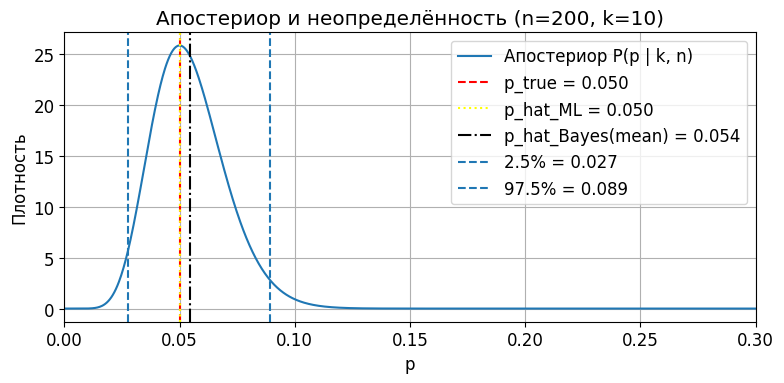

In [239]:
# ЯЧЕЙКА: Апостериор и неопределённость (Bayes = не “другое число”, а распределение и интервал)
# Что делаем:
# 1) Много раз моделируем BSC(p_true) при коротком блоке n=200.
# 2) Берём "типичный" прогон (оценка ML ближе к медиане по всем прогонам).
# 3) Для его (k, n) строим апостериор p|k,n ~ Beta(k+1, n-k+1) при равномерном априоре Beta(1,1).
# 4) Рисуем апостериор и 95% credible interval (2.5%..97.5%), плюс линии p_true, ML и Bayes(mean).

p_true = 0.05
n_bits = 200
n_trials = 5000
alpha, beta = 1.0, 1.0  # равномерный априор Beta(1,1)

res = monte_carlo_compare_ml_bayes(
    p_true=p_true, n_bits=n_bits, n_trials=n_trials,
    alpha=alpha, beta=beta, rng=rng
)

# Берём "типичный" прогон: p_ML ближе всего к медиане
p_ml_all = res["p_ml"]
t = int(np.argmin(np.abs(p_ml_all - np.median(p_ml_all))))

k_t = int(res["k"][t])
p_hat_ml_t = float(res["p_ml"][t])
p_hat_bayes_t = float(res["p_bayes"][t])

# Апостериор по (k_t, n_bits)
p_grid, post_pdf = posterior_beta_grid(k_t, n_bits, num_points=3000)

# 95% credible interval
p02 = posterior_quantile_from_grid(p_grid, post_pdf, 0.025)
p97 = posterior_quantile_from_grid(p_grid, post_pdf, 0.975)

# Текстовый вывод + короткий вывод-смысл
print(f"Типичный прогон: n={n_bits}, k={k_t}")
print(f"Точечные оценки:  p_true={p_true:.4f} | ML={p_hat_ml_t:.4f} | Bayes(mean)={p_hat_bayes_t:.4f}")
print(f"95% credible interval для p: [{p02:.4f}, {p97:.4f}]")

width = p97 - p02
if p02 <= p_true <= p97:
    cover_txt = "p_true попадает в 95% credible interval → наблюдения согласуются с истинным p."
else:
    cover_txt = "p_true НЕ попадает в 95% credible interval → конкретный прогон аномален (редкое отклонение)."

print("\nВывод:")
print(f"- При n={n_bits} неопределённость заметная: ширина 95% интервала ≈ {width:.4f}.")
print(f"- {cover_txt}")
print("- Bayes здесь полезен тем, что даёт распределение/интервал (оценку уверенности), а не только одну точку.")

# График: разные цвета и ограничение оси p до 0.3
plt.figure(figsize=(8,4))

# Апостериор
plt.plot(p_grid, post_pdf, label="Апостериор P(p | k, n)")

# Вертикальные линии 
plt.axvline(p_true, linestyle="--", label=f"p_true = {p_true:.3f}", color='red')
plt.axvline(p_hat_ml_t, linestyle=":", label=f"p_hat_ML = {p_hat_ml_t:.3f}", color='yellow')
plt.axvline(p_hat_bayes_t, linestyle="-.", label=f"p_hat_Bayes(mean) = {p_hat_bayes_t:.3f}", color='black')

plt.axvline(p02, linestyle="--", label=f"2.5% = {p02:.3f}")
plt.axvline(p97, linestyle="--", label=f"97.5% = {p97:.3f}")

plt.xlim(0.0, 0.3)
plt.xlabel("p")
plt.ylabel("Плотность")
plt.title(f"Апостериор и неопределённость (n={n_bits}, k={k_t})")
plt.legend()
plt.tight_layout()
plt.show()


При n=200 апостериорное распределение ещё достаточно широкое: 95% credible interval [0.027,0.089], поэтому точечная оценка 𝑝 имеет заметную неопределённость; истинное ptrue=0.05 лежит внутри интервала, значит эксперимент согласуется с моделью BSC.

In [ ]:
# Сравниваем: ML, Bayes(mean) с равномерным априором и Bayes(mean) с информативным априором

p_true = 0.05
n_bits = 200
n_trials = 5000

# 1) равномерный априор
res_unif = monte_carlo_compare_ml_bayes(
    p_true=p_true, n_bits=n_bits, n_trials=n_trials,
    alpha=1.0, beta=1.0, rng=rng
)

# 2) информативный априор со средним около 0.05:
# mean = alpha/(alpha+beta) = 0.05 -> можно взять (10,190) (сила 200 псевдо-наблюдений)
res_inf = monte_carlo_compare_ml_bayes(
    p_true=p_true, n_bits=n_bits, n_trials=n_trials,
    alpha=10.0, beta=190.0, rng=rng
)

print_report(res_unif, title="=== Uniform prior Beta(1,1) ===")
print()
print_report(res_inf, title="=== Informative prior Beta(10,190) (mean≈0.05) ===")

print("\nКлючевой вывод:")
print(f"ML MSE (baseline):            {res_unif['mse_ml']:.6g}")
print(f"Bayes(mean) MSE uniform prior:{res_unif['mse_bayes']:.6g}")
print(f"Bayes(mean) MSE informative:  {res_inf['mse_bayes']:.6g}")


=== Uniform prior Beta(1,1) ===
p_true=0.05, n=200, trials=5000, prior=(1.0, 1.0)
ML:    mean=0.050301, std=0.015425, bias=0.000301, MSE=0.000237975
Bayes: mean=0.0547535, std=0.0152723, bias=0.00475347, MSE=0.000255793

=== Informative prior Beta(10,190) (mean≈0.05) ===
p_true=0.05, n=200, trials=5000, prior=(10.0, 190.0)
ML:    mean=0.05004, std=0.0152317, bias=4e-05, MSE=0.00023196
Bayes: mean=0.05002, std=0.00761585, bias=2e-05, MSE=5.799e-05

Ключевой вывод:
ML MSE (baseline):            0.000237975
Bayes(mean) MSE uniform prior:0.000255793
Bayes(mean) MSE informative:  5.799e-05


ML — хороший базовый метод без предположений (почти без смещения), но на коротких блоках шумный. Байесовская оценка выигрывает, если априор отражает реальные ожидания по каналу: тогда разброс и MSE сильно уменьшаются. Если априор выбран неудачно (например, равномерный при малых p), можно получить смещение и ухудшение.

p_true=0.001, n=200, trials=10000
Доля прогонов с k=0 (ML=0): 0.821
При k=0: ML=0, Bayes(mean)=0.0049505, 95% upper bound=0.0145463


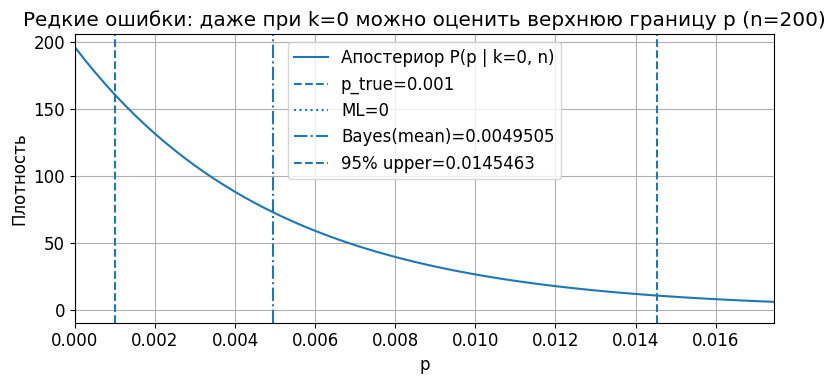

In [ ]:
# “редкие ошибки”: ML часто даёт 0, а Байес даёт верхнюю границу (95% upper)
# Тут смысл не в MSE точечных оценок, а в оценке риска: насколько большим может быть p.

p_true = 1e-3
n_bits = 200
n_trials = 10000
alpha, beta = 1.0, 1.0

res_rare = monte_carlo_compare_ml_bayes(
    p_true=p_true, n_bits=n_bits, n_trials=n_trials,
    alpha=alpha, beta=beta, rng=rng
)

zero_rate = float(np.mean(res_rare["k"] == 0))
print(f"p_true={p_true}, n={n_bits}, trials={n_trials}")
print(f"Доля прогонов с k=0 (ML=0): {zero_rate:.3f}")

# Покажем постериор для типичного случая k=0
k0 = 0
p_grid0, post_pdf0 = posterior_beta_grid(k0, n_bits, num_points=4000)
p95 = posterior_quantile_from_grid(p_grid0, post_pdf0, 0.95)

p_ml0 = 0.0
p_bayes0 = (alpha + k0) / (alpha + beta + n_bits)

print(f"При k=0: ML={p_ml0:g}, Bayes(mean)={p_bayes0:g}, 95% upper bound={p95:g}")

plt.figure(figsize=(8,4))
plt.plot(p_grid0, post_pdf0, label="Апостериор P(p | k=0, n)")
plt.axvline(p_true, linestyle="--", label=f"p_true={p_true:g}")
plt.axvline(p_ml0, linestyle=":", label="ML=0")
plt.axvline(p_bayes0, linestyle="-.", label=f"Bayes(mean)={p_bayes0:g}")
plt.axvline(p95, linestyle="--", label=f"95% upper={p95:g}")

plt.xlim(0, max(5*p_true, p95*1.2))
plt.xlabel("p")
plt.ylabel("Плотность")
plt.title(f"Редкие ошибки: даже при k=0 можно оценить верхнюю границу p (n={n_bits})")
plt.legend()
plt.tight_layout()
plt.show()


При малом p и коротком блоке n ML-оценка часто равна нулю, поэтому она не подходит для оценки риска. Байесовский подход даёт апостериор и позволяет получить верхнюю границу: при k=0 и n=200 95%-я верхняя граница p составляет ≈0.0145, то есть мы можем количественно оценить “насколько плохим может быть канал”, даже не наблюдая ошибок.

## **Результаты и применимость**

#### Краткие выводы экспериментов

- При коротком блоке (\(n=200\)) апостериорное распределение \(p\) остаётся широким, а неопределённость оценки велика — по малому числу бит параметр канала определяется неточно.
- При увеличении длины блока апостериор сужается, а оценки \(\hat p_{\text{ML}}\) и \(\hat p_{\text{Bayes}}\) сходятся; влияние априора становится несущественным.
- Байесовский подход важен не столько точечной оценкой, сколько возможностью получить апостериор и доверительный (credible) интервал для \(p\).
- В режиме редких ошибок (\(k=0\)) частотная оценка \(\hat p_{\text{ML}}=0\) неинформативна, тогда как Байес позволяет получить верхнюю границу на \(p\).
- При наличии информативного априора байесовская оценка существенно снижает разброс и MSE на коротких выборках по сравнению с ML.

#### Практический смысл

- Байесовская оценка позволяет учитывать неопределённость и риск при оценке BER, а не опираться на одно число.
- Метод полезен для коротких пакетов и планирования измерений: по ширине апостериора можно оценить, сколько данных нужно для надёжной оценки качества канала



#### Как это можно использовать

- **Онлайн-оценка BER.**  
  Точно так же оценивают качество радиолинии по пилотам/служебным данным, чтобы выбирать модуляцию, код и решать, нужны ли ретрансмиссии.

- **Короткие пакеты.**  
  При малом числе бит обычная оценка $k/n$ может сильно прыгать. Байес даёт более стабильное значение и понятный диапазон правдоподобных $p$.

- **Планирование измерений.**  
  По сужению апостериора видно, сколько бит нужно прогнать через канал, чтобы оценить BER с нужной точностью.

Модель BSC простая, но даёт реалистичную схему оценки качества линка и легко обобщается на более сложные каналы.


## **Литература**

https://ru.wikipedia.org/wiki/Двоичный_симметричный_канал   
https://ru.wikipedia.org/wiki/Пропускная_способность_канала   
https://en.wikipedia.org/wiki/Bit_error_rate    
https://habr.com/ru/articles/251693/   
https://ru.wikipedia.org/wiki/Биномиальное_распределение     
https://ru.wikipedia.org/wiki/Байесовский_вывод 

